In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_E_utt = pd.read_csv("combined_utt_sent_E.csv")
df_T_utt = pd.read_csv("combined_utt_sent_T.csv")
df_M_utt = pd.read_csv("combined_utt_sent_M.csv")

/var/folders/7t/rp_1dcrj5nv_nqhf5_82lk3h0000gn/T/ipykernel_19142/298430867.py:1: DtypeWarning: Columns (0: top_level_comment) have mixed types. Specify dtype option on import or set low_memory=False.
  df_E_utt = pd.read_csv("combined_utt_sent_E.csv")
/var/folders/7t/rp_1dcrj5nv_nqhf5_82lk3h0000gn/T/ipykernel_19142/298430867.py:2: DtypeWarning: Columns (0: top_level_comment) have mixed types. Specify dtype option on import or set low_memory=False.
  df_T_utt = pd.read_csv("combined_utt_sent_T.csv")
/var/folders/7t/rp_1dcrj5nv_nqhf5_82lk3h0000gn/T/ipykernel_19142/298430867.py:3: DtypeWarning: Columns (0: top_level_comment) have mixed types. Specify dtype option on import or set low_memory=False.
  df_M_utt = pd.read_csv("combined_utt_sent_M.csv")


### Top X N-grams

In [3]:
import re
import nltk
import unicodedata
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt_tab')
nltk.download('stopwords')

wnl = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/yusufabdelnur/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/yusufabdelnur/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/yusufabdelnur/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/yusufabdelnur/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# pos (str) – The Part Of Speech tag. 
# Valid options are 
#   “n” for nouns, “v” for verbs, “a” for adjectives, 
#   “r” for adverbs and “s” for satellite adjectives.

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return "a"
    elif treebank_tag.startswith('V'):
        return "v"
    elif treebank_tag.startswith('N'):
        return "n"
    elif treebank_tag.startswith('R'):
        return "r"
    else:
        return 'n'


In [5]:
stop_words = (stopwords.words('english'))

extra_stopwords = [
    "like","get","got","would","one","time","really",
    "people","think","know","see","also","even","still",
    "im","dont","cant","could","us","go","going","back",
    "game","team","play","played","playing", "make"
]

domain_specific_stopwords = [
    "doom", "destiny", "star", "wars", "battlefront", "splatoon", 
    "gw", "garden", "warfare" "gw2", "gw3", "cod", "call", "of", "duty",
    "black", "ops", "remove", "post", "automaticly", "performed", "flair", "removed"
]

special_tokens = ["NUM", "URL"]

stop_words = stop_words + domain_specific_stopwords + extra_stopwords + special_tokens

In [6]:
def clean_text(text):
    text = str(text)

    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode("utf-8", "ignore")

    text = text.lower()

    text = re.sub(r"http\S+|www\S+", " URL ", text)
    text = re.sub(r"\d+", " NUM ", text)

    text = text.replace("\n", " ").replace("\r", " ")
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [7]:
def tokenize(text):
    tokens = []

    for token in nltk.pos_tag(word_tokenize(text)):
        wrd = token[0]
        pos = token[1]

        if wrd.isalpha() and len(wrd) > 2:
            lemma = wnl.lemmatize(wrd, get_wordnet_pos(pos))

            if lemma not in stop_words:
                tokens.append(lemma)

    return tokens

In [8]:
from collections import Counter

def get_ngrams(df, text_col="text", top_n=100):
    unigram_counter = Counter()
    bigram_counter = Counter()

    texts = df[text_col].dropna()

    for text in texts:
        clean = clean_text(text)      
        tokens = tokenize(clean)      

        unigram_counter.update(tokens)
        bigram_counter.update(zip(tokens, tokens[1:]))
    
    return (
        unigram_counter.most_common(top_n),
        bigram_counter.most_common(top_n),
    )

In [9]:
def plot_ngrams(unigrams, bigrams, rating=""):
    
    words, counts = zip(*unigrams)

    plt.figure()
    plt.bar(words[1:20], counts[1:20])
    plt.xticks(rotation=45)
    plt.title(f"Top Unigrams - {rating} Rated")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    bigram_labels = [" ".join(bg) for bg, _ in bigrams]
    bigram_counts = [count for _, count in bigrams]

    plt.figure()
    plt.bar(bigram_labels[1:20], bigram_counts[1:20])
    plt.xticks(rotation=45)
    plt.title(f"Top Bigrams - {rating} Rated")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [10]:
def plot_ngrams_hor(unigrams, bigrams, rating=""):
    
    def plot_barh(labels, counts, title):
        plt.figure()
        plt.barh(labels, counts)
        plt.xlabel("Frequency")
        plt.title(title)
        plt.gca().invert_yaxis() 
        plt.tight_layout()
        plt.show()

    words, counts = zip(*unigrams)
    plot_barh(words, counts, f"Top Unigrams - {rating} Rated")

    bigram_labels = [" ".join(bg) for bg, _ in bigrams]
    bigram_counts = [count for _, count in bigrams]
    plot_barh(bigram_labels, bigram_counts, f"Top Bigrams - {rating} Rated")

Plotting unigrams and bigrams without removing special tokens (showing how num is an interesting quantifier)

In [11]:
unigrams_M, bigrams_M = get_ngrams(df_M_utt)

print("Top M unigrams:", unigrams_M)
print("Top M bigrams:", bigrams_M)

Top M unigrams: [('use', 33503), ('good', 28991), ('kill', 25032), ('say', 22216), ('map', 21233), ('well', 20050), ('want', 19155), ('weapon', 18908), ('look', 18569), ('try', 18467), ('player', 18110), ('much', 17429), ('thing', 17385), ('way', 15835), ('take', 15302), ('run', 15006), ('work', 14719), ('need', 14690), ('new', 14194), ('gun', 14064), ('find', 13354), ('first', 13290), ('level', 12365), ('come', 12118), ('give', 11812), ('lot', 11770), ('something', 11741), ('pretty', 11648), ('feel', 11558), ('point', 11490), ('bad', 11413), ('though', 11393), ('right', 11201), ('every', 11006), ('never', 10999), ('sure', 10506), ('since', 10253), ('actually', 10150), ('mean', 10107), ('guy', 9925), ('love', 9833), ('start', 9602), ('hell', 9323), ('seem', 9320), ('enemy', 9000), ('around', 8862), ('day', 8800), ('yeah', 8750), ('fun', 8746), ('fuck', 8618), ('always', 8618), ('maybe', 8346), ('great', 8345), ('long', 8316), ('shit', 8286), ('mode', 8098), ('demon', 7954), ('probably'

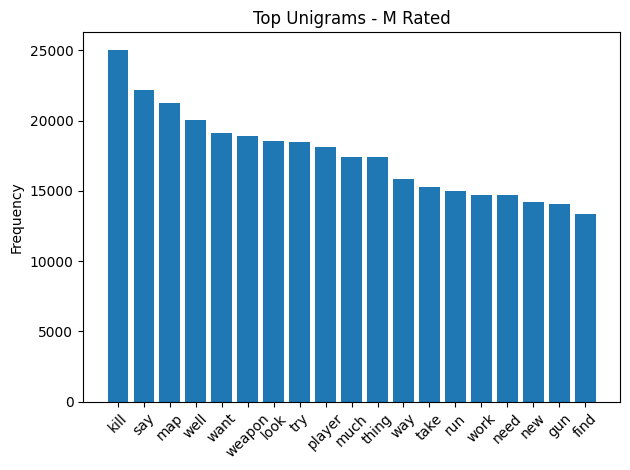

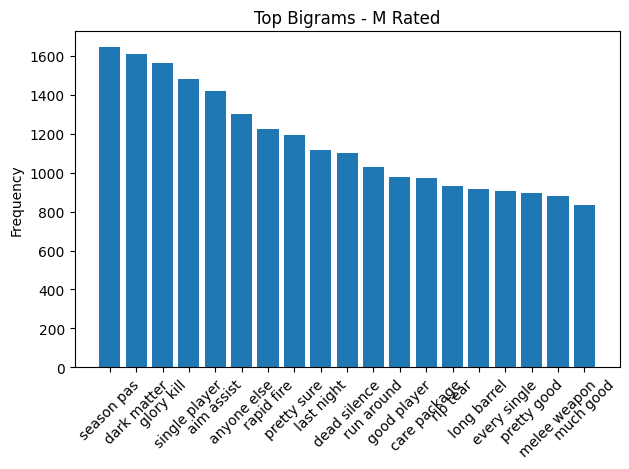

In [12]:
plot_ngrams(unigrams_M[1:], bigrams_M[1:], rating="M")

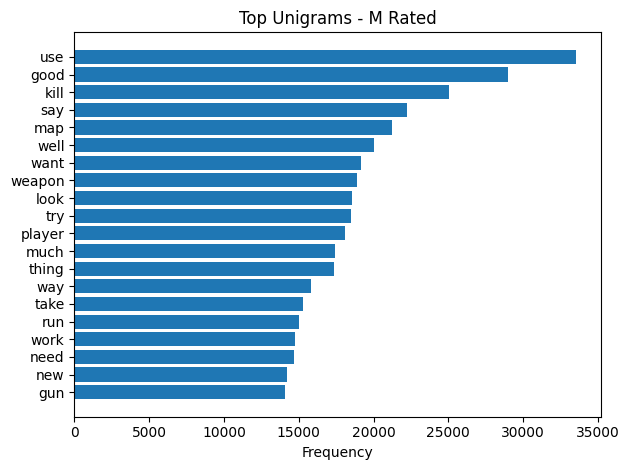

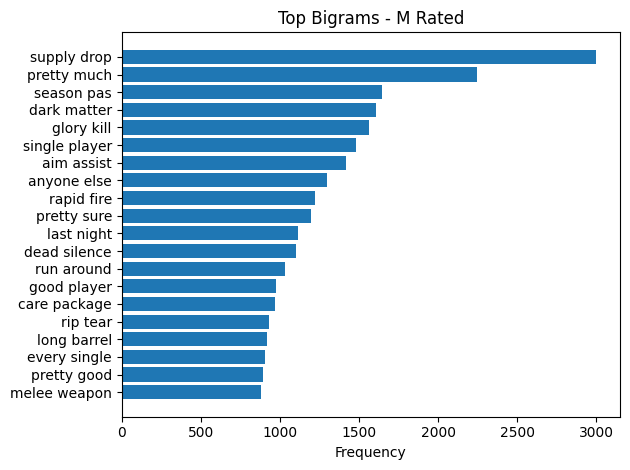

In [21]:
plot_ngrams_hor(unigrams_M[0:20], bigrams_M[0:20], "M")

In [14]:
unigrams_T, bigrams_T = get_ngrams(df_T_utt)

print("Top T unigrams:", unigrams_T)
print("Top T bigrams:", bigrams_T)

Top T unigrams: [('good', 27511), ('use', 25362), ('say', 24822), ('want', 24232), ('look', 22502), ('player', 19868), ('well', 19566), ('thing', 18157), ('much', 17304), ('take', 16919), ('need', 16513), ('new', 16506), ('way', 16325), ('map', 15004), ('try', 14857), ('kill', 14802), ('hero', 14337), ('first', 13936), ('give', 13892), ('come', 13560), ('work', 13505), ('clan', 12686), ('point', 12628), ('buy', 12259), ('right', 12181), ('feel', 12154), ('find', 11703), ('something', 11411), ('weapon', 11324), ('level', 11254), ('lot', 11154), ('mean', 11082), ('run', 11038), ('dlc', 10921), ('war', 10799), ('sure', 10698), ('though', 10694), ('raid', 10656), ('mode', 10656), ('fun', 10627), ('pretty', 10432), ('every', 10177), ('actually', 10157), ('never', 10077), ('content', 9913), ('bad', 9660), ('since', 9598), ('yeah', 9523), ('love', 9482), ('day', 9210), ('seem', 8936), ('add', 8734), ('change', 8675), ('start', 8550), ('around', 8490), ('drop', 8467), ('maybe', 8195), ('keep',

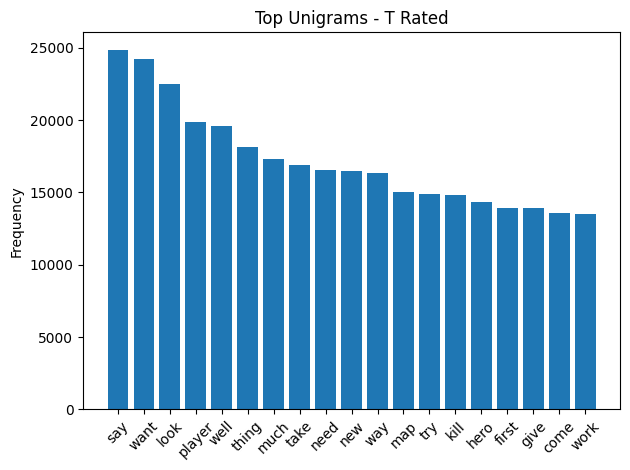

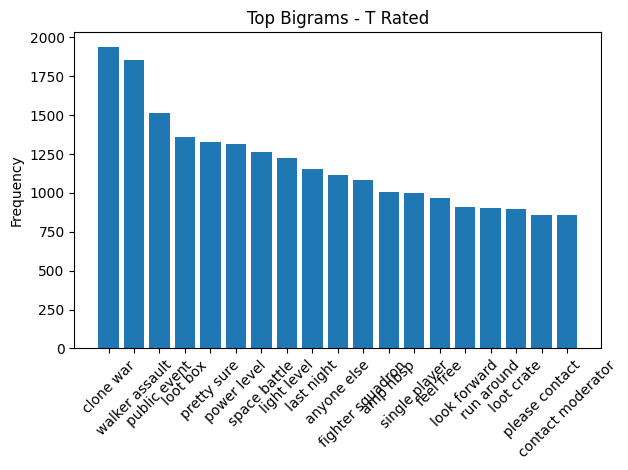

In [15]:
plot_ngrams(unigrams_T[1:], bigrams_T[1:], "T")

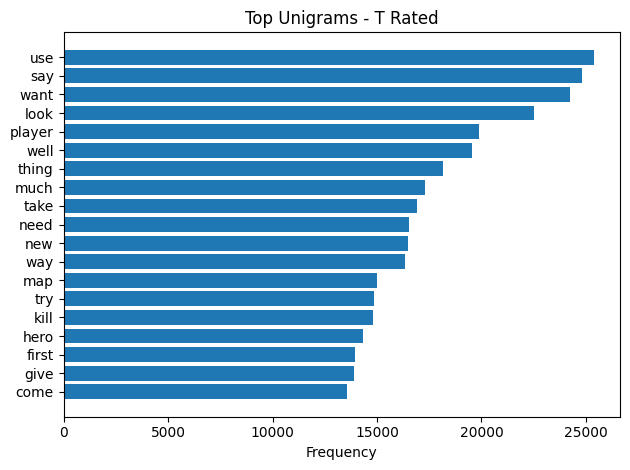

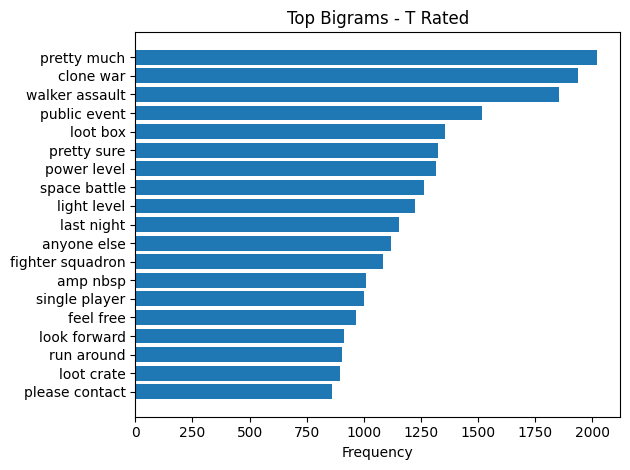

In [16]:
plot_ngrams_hor(unigrams_T[1:20], bigrams_T[1:20], "T")

In [17]:
unigrams_E, bigrams_E = get_ngrams(df_E_utt)

print("Top E unigrams:", unigrams_E)
print("Top E bigrams:", bigrams_E)

Top E unigrams: [('use', 33997), ('good', 31007), ('well', 20790), ('player', 20615), ('say', 20245), ('much', 18532), ('need', 17799), ('try', 17786), ('want', 17608), ('weapon', 17262), ('take', 17078), ('damage', 16598), ('character', 16135), ('thing', 16096), ('way', 15969), ('kill', 15729), ('look', 13891), ('ink', 13605), ('point', 13272), ('though', 12953), ('rank', 12931), ('match', 12748), ('new', 12435), ('lot', 12317), ('map', 12077), ('right', 11893), ('give', 11843), ('work', 11822), ('first', 11722), ('pretty', 11440), ('actually', 11440), ('zombie', 11347), ('come', 11304), ('bad', 11153), ('find', 11078), ('win', 11022), ('mean', 11016), ('ability', 10875), ('since', 10857), ('range', 10831), ('something', 10663), ('mode', 10343), ('feel', 10171), ('level', 9993), ('every', 9764), ('never', 9693), ('plant', 9637), ('sure', 9579), ('around', 9314), ('seem', 9229), ('start', 9194), ('enemy', 9028), ('fun', 8899), ('day', 8860), ('maybe', 8860), ('long', 8838), ('yeah', 87

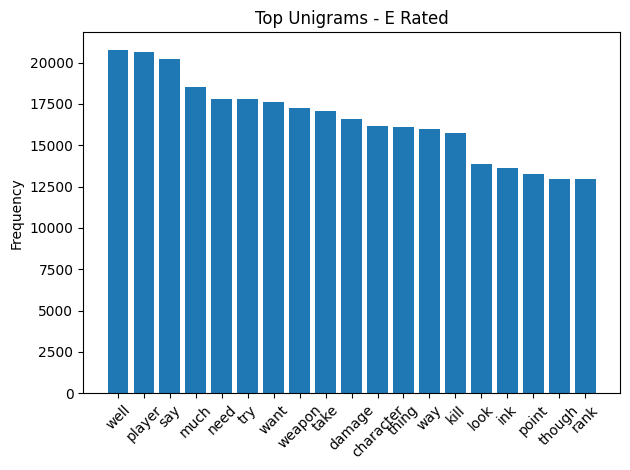

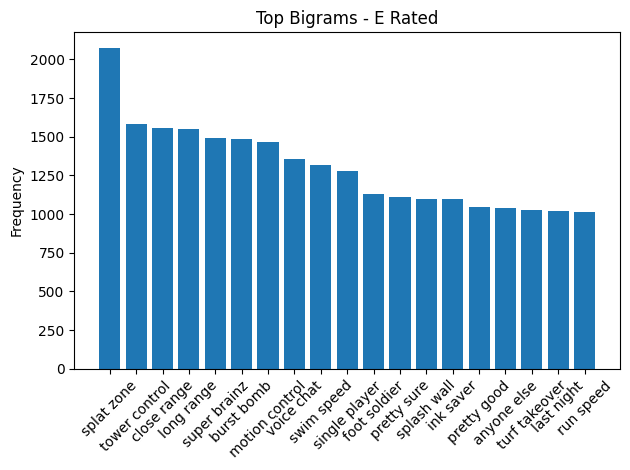

In [18]:
plot_ngrams(unigrams_E[1:], bigrams_E[1:], "E")

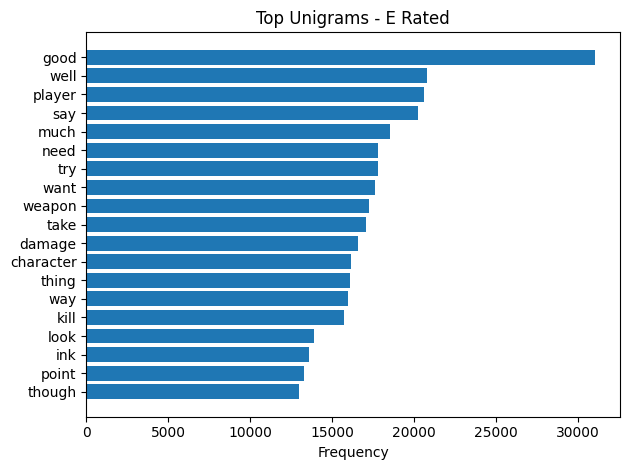

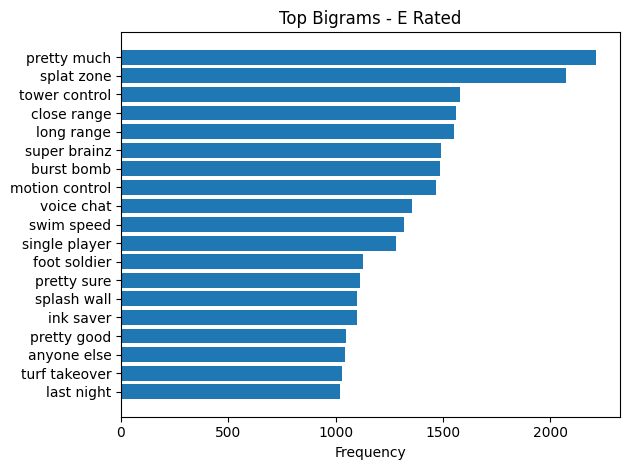

In [19]:
plot_ngrams_hor(unigrams_E[1:20], bigrams_E[1:20], "E")